## Introduction

This project covers all the most common aspects of Data Cleaning with Pandas, using a dataset scraped from the Google Playstore.

As you might know, scraping data usually produces incorrect results.

This project includes several cleaning tasks (ranging from invalid values, to missing / duplicate values) and finished with several analysis tasks.

We encourage you to use visualizations as much as possible to understand the data as well as the [missingno](https://github.com/ResidentMario/missingno) library, which is already installed, imported and ready to use.

>
> Important! Please make sure to resolve activities in order for them to work properly. > > Some of the latest activities rely on the first ones to be completed to work.
>

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [36]:
df = pd.read_csv('data/googleplaystore.csv')

In [37]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,2M,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## Missingno Library:

`missingno` is a Python library for visualizing missing data in pandas DataFrames. It helps you quickly understand patterns of missing values, which is crucial for data cleaning and preprocessing.

### 2️⃣ Why Missingno?

When you have a dataset:
- Some values may be missing (`NaN`)
- Handling them without insight can lead to incorrect analysis
- `missingno` provides visualizations to detect patterns in missing data, including:
  - Which columns have missing data
  - How much is missing
  - Correlations between missingness of different columns

### 3️⃣ Core Functions & Operations
#### A. Matrix Plot

Visualizes missing data row-wise in your dataset.
```python
msno.matrix(df)
```

How it works:
- Each row = one record
- Each column = one feature
- White lines = missing values
- Grey/black = present data
- Can include correlation between missing values with `sparkline=True`

**Use case**: Quickly see where **missing values appear in rows**.

#### B. Bar Chart

Shows number of non-missing values per column.
```python
msno.bar(df)
```

How it works:
- Each bar = one column
- Height = count of non-missing values
- Missing values = difference from max bar height

**Use case**: Best for comparing columns and identifying which columns have most missing data.

#### C. Heatmap

Shows correlation between missing values across columns.
```python
msno.heatmap(df)
```

How it works:
- Measures nullity correlation: how the absence in one column is related to another
- Color indicates correlation:
  - 1 → strongly correlated missingness
  - 0 → independent
- Useful for feature engineering or imputing missing values

**Use case**: Detect columns that are missing together.

#### D. Integration with Pandas

You can directly analyze missing data before visualizing:
```python
df.isnull().sum()  # Number of missing values per column
df.isnull().mean() # Percentage of missing values per column
```

**`missingno`** complements these pandas operations with visual intuition.

#### E. Nullity Matrix / Heatmap Options

All functions accept options like:
```python
msno.matrix(df, figsize=(10,5), sparkline=False)
msno.bar(df, figsize=(10,5), color='skyblue')
msno.heatmap(df, figsize=(8,6), cmap='viridis')
msno.dendrogram(df, figsize=(10,5))
```

- `figsize` → size of plot
- `color / cmap` → customize colors
- `sparkline` → small summary line for the matrix

<Axes: >

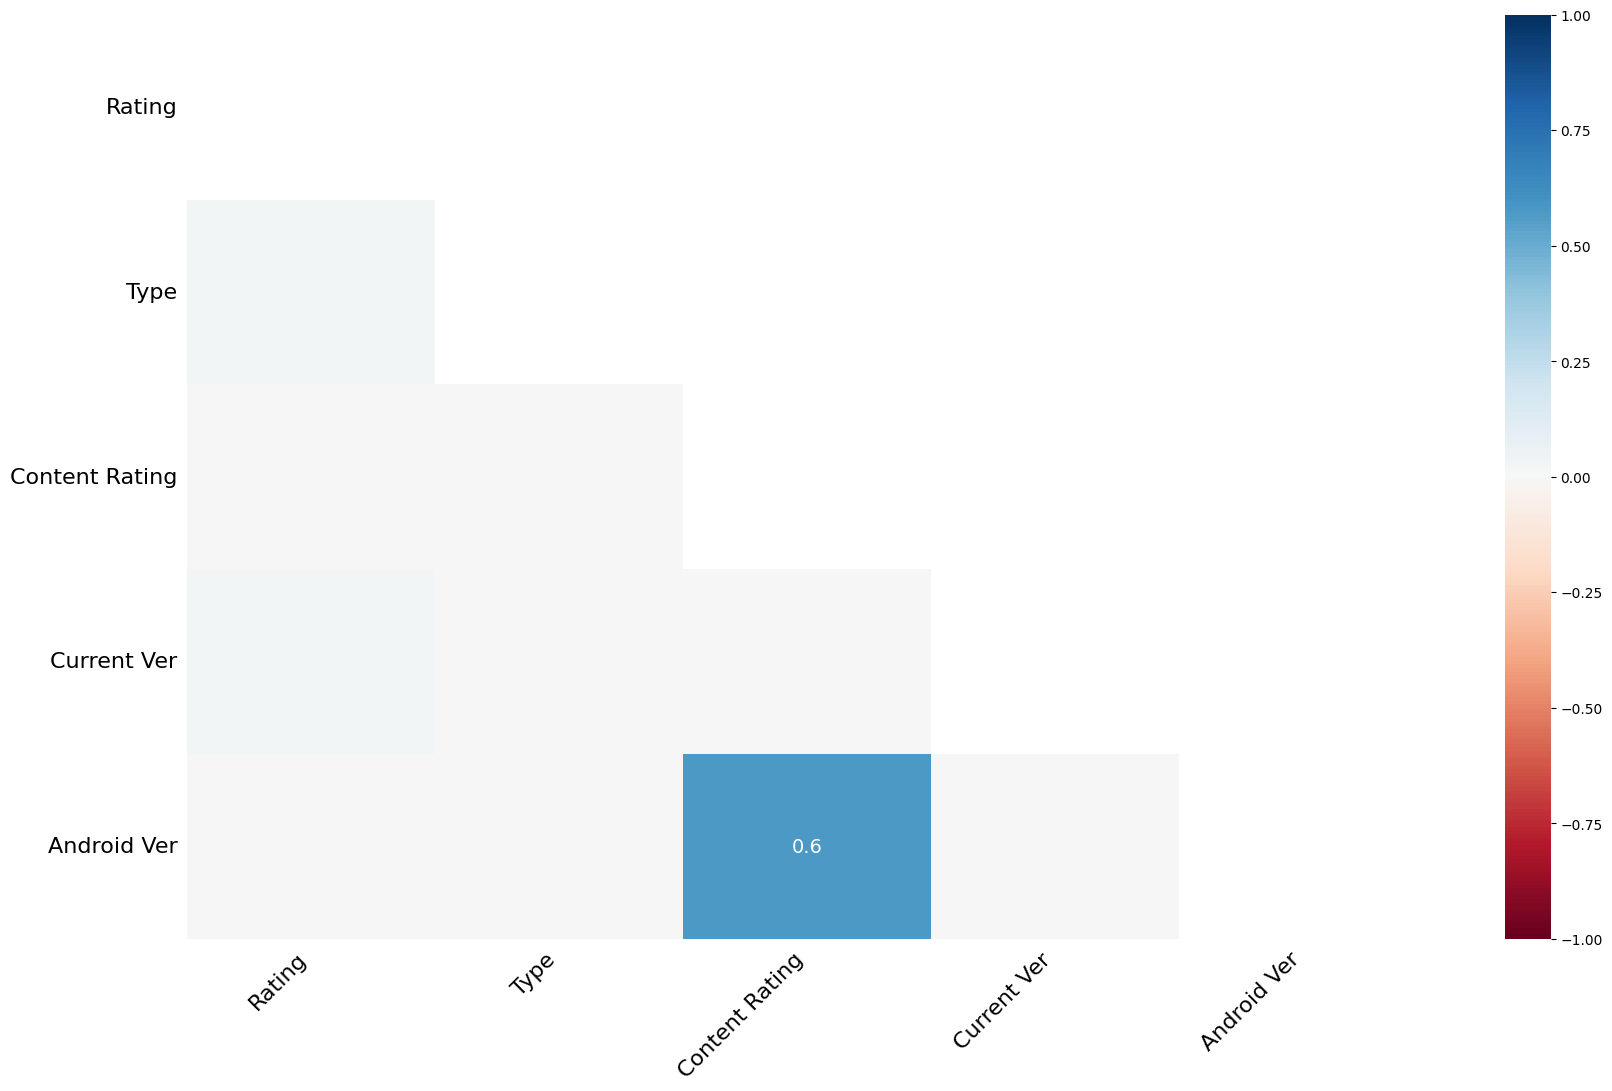

In [38]:
msno.heatmap(df)

<Axes: >

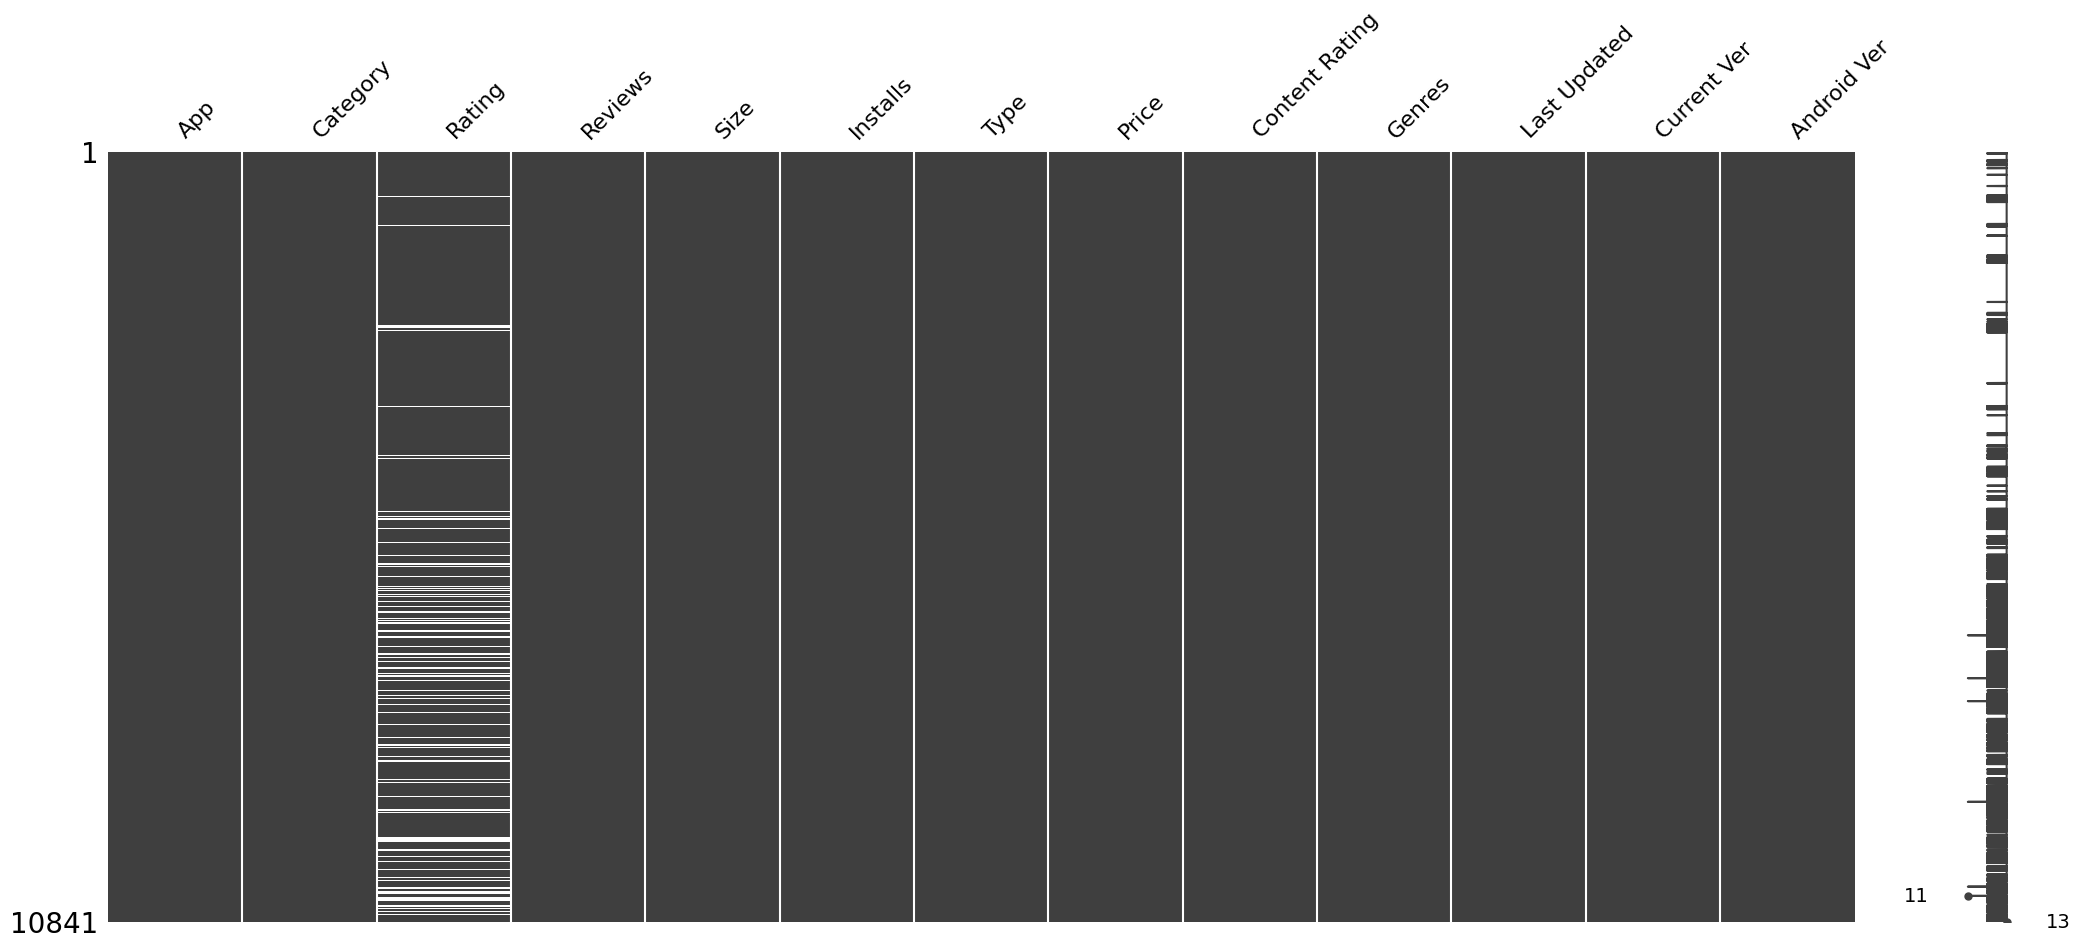

In [39]:
msno.matrix(df)

#### 1. Select the columns that you have identified having null/missing values. We encourage you to use the missingno library.

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


<Axes: >

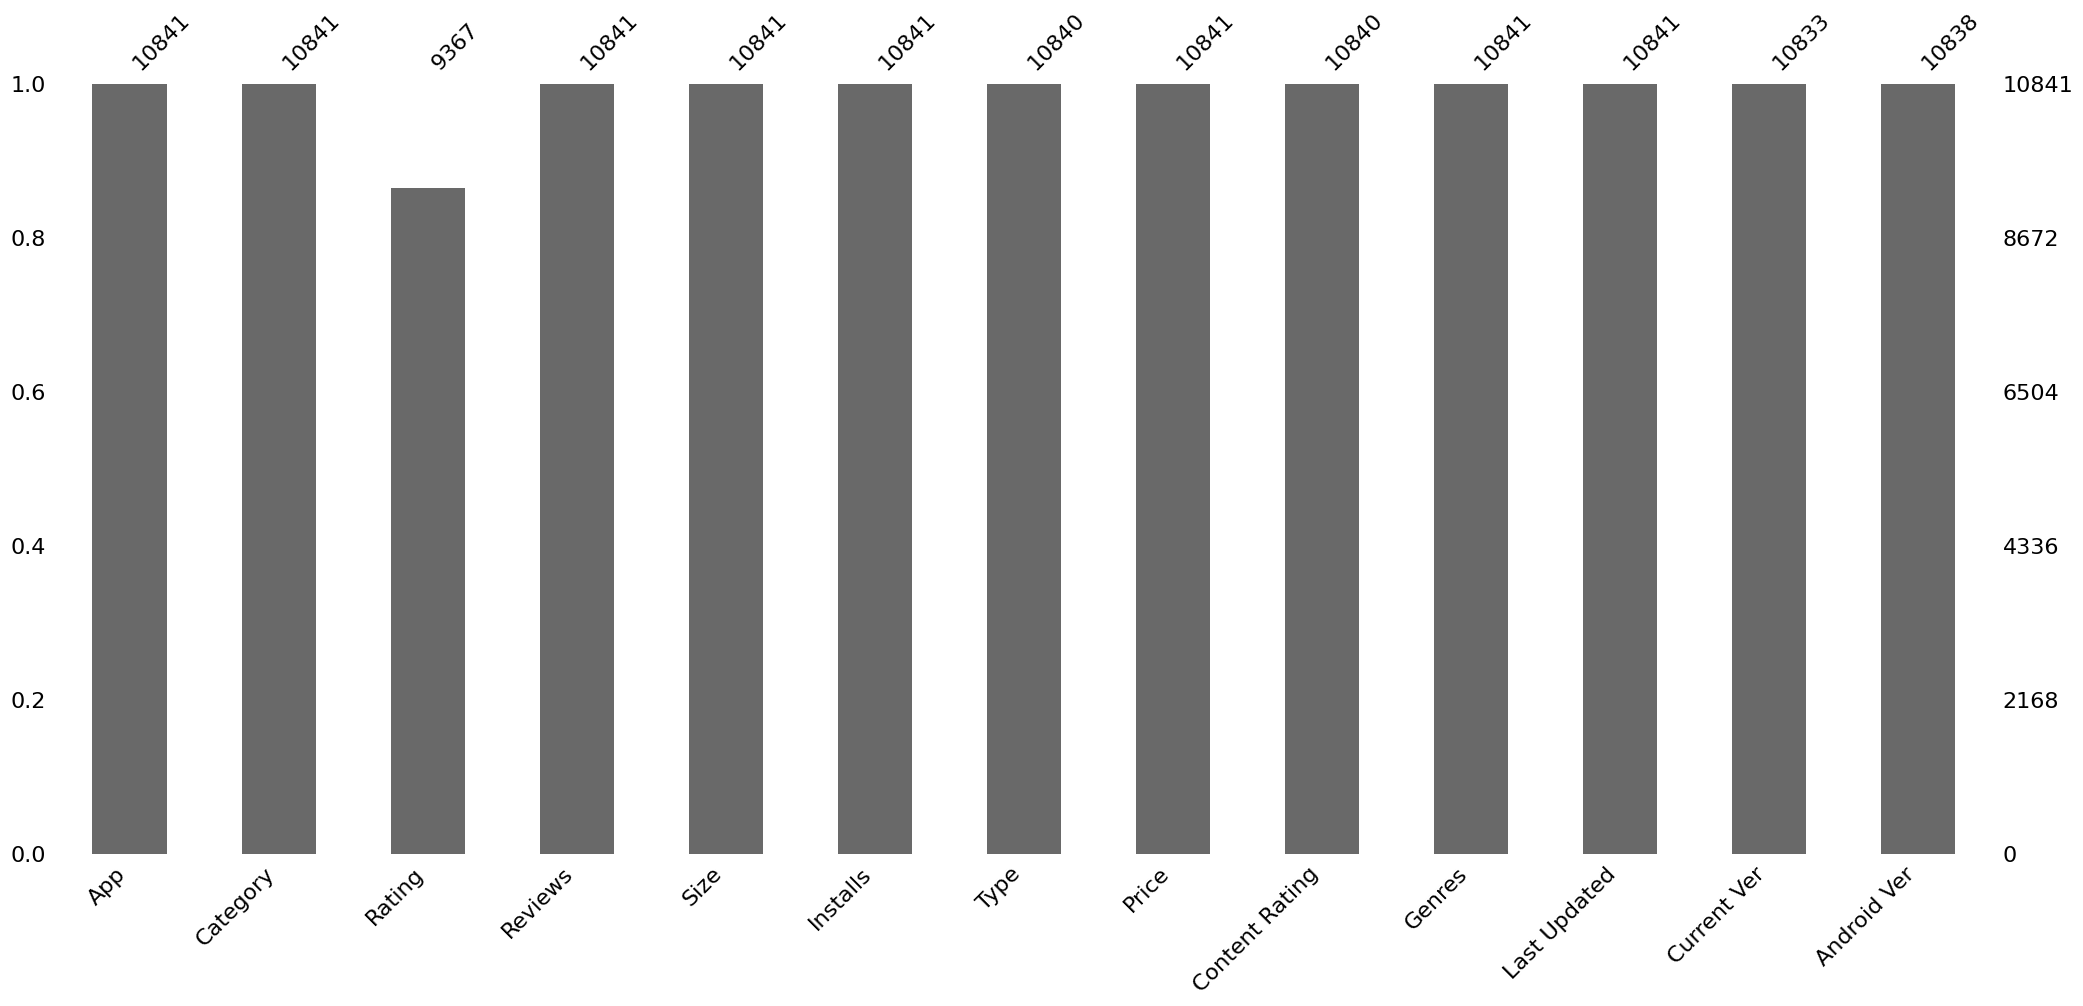

In [41]:
msno.bar(df)

In [42]:
df.isna().sum().sort_values(ascending=False)

# going to measure how many null vlaues available in the dataframe.

Rating            1474
Current Ver          8
Android Ver          3
Type                 1
Content Rating       1
App                  0
Category             0
Reviews              0
Size                 0
Installs             0
Price                0
Genres               0
Last Updated         0
dtype: int64

In [43]:
df.isnull().sum().sort_values(ascending=False)

# going to measure how many null vlaues available in the dataframe.

Rating            1474
Current Ver          8
Android Ver          3
Type                 1
Content Rating       1
App                  0
Category             0
Reviews              0
Size                 0
Installs             0
Price                0
Genres               0
Last Updated         0
dtype: int64

#### 2. Clean the Rating column and the other columns containing null values

This is a 3-part activity:

- Remove the invalid values from `Rating` (if any). Just set them as `NaN`.
- Fill the null values in the `Rating` column using the `mean()`
- Clean any other non-numerical columns by just dropping the values.

Perform the modifications "in place", modifying `df`. If you make a mistake, re-load the data.

>> All the ratings that are not in the range of 0 to 5 should be replaced with `NaN`.
>> 
>> For the other columns, just drop the rows that contain null values.

<Axes: ylabel='Frequency'>

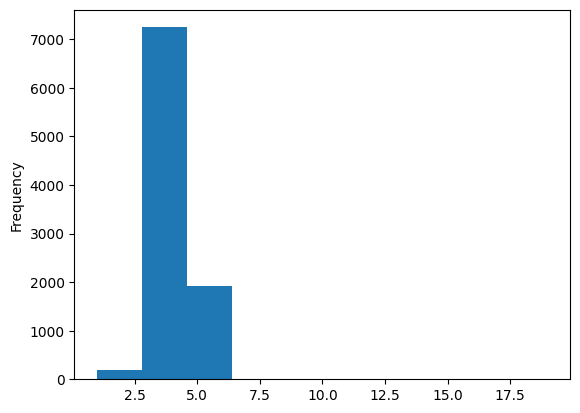

In [44]:
df['Rating'].plot(kind='hist')

<Axes: >

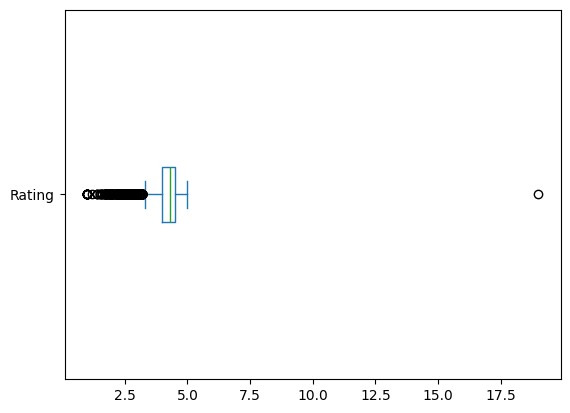

In [45]:
df['Rating'].plot(kind='box', vert=False)

In [46]:
df['Rating'].describe()

count    9367.000000
mean        4.193338
std         0.537431
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max        19.000000
Name: Rating, dtype: float64

In [47]:
df.loc[df['Rating'] > 5]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [48]:
df.loc[df['Rating'] > 5, 'Rating'] = np.nan

In [49]:
df['Rating'].mean()

np.float64(4.191757420456972)

In [50]:
df['Rating'].fillna(df['Rating'].mean(), inplace=True)

/var/folders/zs/6h03lndj5114078br2jdh8380000gn/T/ipykernel_69591/1501272357.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].mean(), inplace=True)


In [51]:
df.dropna(inplace=True)

#### 3. Clean the column Reviews and make it numeric

You'll notice that some columns from this dataframe which should be numeric, were parsed as `object` (string). That's because sometimes the numbers are expressed with `M`, or `k` to indicate `Mega` or `kilo`.

Clean the `Reviews` column by transforming the values to the correct numeric representation. For example, `5M` should be `5000000`.

In [52]:
df['Reviews'].head()

0      159
1      967
2    87510
3       2M
4      967
Name: Reviews, dtype: object

In [54]:
df['Reviews Numeric'] = pd.to_numeric(df['Reviews'], errors='coerce')

In [56]:
df.loc[df['Reviews Numeric'].isna()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,2M,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,NaN
37,Floor Plan Creator,ART_AND_DESIGN,4.1,3M,Varies with device,"5,000,000+",Free,0,Everyone,Art & Design,"July 14, 2018",Varies with device,2.3.3 and up,NaN
79,Tickets + PDA 2018 Exam,AUTO_AND_VEHICLES,4.9,1M,38M,"1,000,000+",Free,0,Everyone,Auto & Vehicles,"July 15, 2018",8.31,4.1 and up,NaN
2134,Inside Out Thought Bubbles,FAMILY,4.4,6M,58M,"10,000,000+",Free,0,Everyone,Puzzle;Brain Games,"August 31, 2017",1.22.0,4.0.3 and up,NaN
2210,Barbie Life™,FAMILY,3.9,1M,63M,"5,000,000+",Free,0,Everyone,Casual;Pretend Play,"July 12, 2018",2.6,4.1 and up,NaN


In [57]:
df.loc[df['Reviews'].str.contains('M')]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,2M,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,NaN
37,Floor Plan Creator,ART_AND_DESIGN,4.1,3M,Varies with device,"5,000,000+",Free,0,Everyone,Art & Design,"July 14, 2018",Varies with device,2.3.3 and up,NaN
79,Tickets + PDA 2018 Exam,AUTO_AND_VEHICLES,4.9,1M,38M,"1,000,000+",Free,0,Everyone,Auto & Vehicles,"July 15, 2018",8.31,4.1 and up,NaN
2134,Inside Out Thought Bubbles,FAMILY,4.4,6M,58M,"10,000,000+",Free,0,Everyone,Puzzle;Brain Games,"August 31, 2017",1.22.0,4.0.3 and up,NaN
2210,Barbie Life™,FAMILY,3.9,1M,63M,"5,000,000+",Free,0,Everyone,Casual;Pretend Play,"July 12, 2018",2.6,4.1 and up,NaN


In [58]:
df.loc[df['Reviews'].str.contains('M'), 'Reviews']

3       2M
37      3M
79      1M
2134    6M
2210    1M
Name: Reviews, dtype: object

In [59]:
df.loc[df['Reviews'].str.contains('M'), 'Reviews'].str.replace('M', ' ')

3       2 
37      3 
79      1 
2134    6 
2210    1 
Name: Reviews, dtype: object

In [67]:
pd.to_numeric(df.loc[df['Reviews'].str.contains('M'), 'Reviews'].str.replace('M', ' ')
              ) * 1_000_000

Series([], Name: Reviews, dtype: int64)

In [68]:
new_reviews = (
  pd.to_numeric(df.loc[df['Reviews'].str.contains('M'), 'Reviews'].str.replace('M', ' '))
                * 1_000_000
).astype(str)
new_reviews

Series([], Name: Reviews, dtype: object)

In [69]:
df.loc[df['Reviews'].str.contains('M'), 'Reviews'] = (
  pd.to_numeric(df.loc[df['Reviews'].str.contains('M'), 'Reviews'].str.replace('M', ' '))
                * 1_000_000
).astype(str)

In [70]:
df.loc[[3, 37, 79, 2134, 2210]]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,2000000,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,NaN
37,Floor Plan Creator,ART_AND_DESIGN,4.1,3000000,Varies with device,"5,000,000+",Free,0,Everyone,Art & Design,"July 14, 2018",Varies with device,2.3.3 and up,NaN
79,Tickets + PDA 2018 Exam,AUTO_AND_VEHICLES,4.9,1000000,38M,"1,000,000+",Free,0,Everyone,Auto & Vehicles,"July 15, 2018",8.31,4.1 and up,NaN
2134,Inside Out Thought Bubbles,FAMILY,4.4,6000000,58M,"10,000,000+",Free,0,Everyone,Puzzle;Brain Games,"August 31, 2017",1.22.0,4.0.3 and up,NaN
2210,Barbie Life™,FAMILY,3.9,1000000,63M,"5,000,000+",Free,0,Everyone,Casual;Pretend Play,"July 12, 2018",2.6,4.1 and up,NaN


In [71]:
df['Reviews'] = pd.to_numeric(df['Reviews'])

#### 4. How many duplicated apps are there?

Count the number of duplicated rows. That is, if the app `Twitter` appears 2 times, that counts as 2.

In [72]:
df.duplicated(keep=False).sum()

np.int64(891)

In [73]:
df.duplicated(subset=['App'], keep=False).sum()

np.int64(1979)

### 🧩 Your two lines

```python
df.duplicated(subset=['App'], keep=False).sum()   # → 1979
df.duplicated(keep=False).sum()                   # → 891
```

And you’re wondering why the counts (1979 vs 891) are different.

### 🔹 What `.duplicated()` actually does

`df.duplicated()` returns a Boolean Series —
`True` for rows that are duplicates of a previous row, according to whatever subset of columns you specify.

- subset → which columns to consider for checking duplicates
- keep → which duplicates to mark as `False` (keep):
  - `'first'` → mark duplicates after the first as `True`
  - `'last'` → mark duplicates before the last as `True`
  - `False` → mark all duplicates as `True` (no one is “kept”)

### 🔹 Line 1 — Using `subset=['App']`
```python
df.duplicated(subset=['App'], keep=False).sum()
```

This looks for duplicate “App” names only — ignoring all other columns.

✅ It counts how many rows have the same value in the `"App"` column.

So if `"Facebook"` appears 5 times, all 5 are marked `True`.

Hence you get 1979 duplicated rows — meaning 1979 rows share an `"App"` value that appears more than once, regardless of their other columns.

### 🔹 Line 2 — Without subset

```python
df.duplicated(keep=False).sum()
```

This considers the entire row — all columns — when checking for duplicates.

✅ A row is only marked as duplicate if every single column’s value matches another row exactly.

That’s stricter, so naturally you get fewer duplicates (891) — only those rows that are identical in all columns.

### Simple Examples
| App       | Category | Rating |
| :---------: | :--------: | :------: |
| Facebook  | Social   | 4.5    |
| Facebook  | Social   | 4.6    |
| Instagram | Photo    | 4.4    |
| Instagram | Photo    | 4.4    |

Now:
```python
df.duplicated(subset=['App'], keep=False)
# True, True, True, True
```
(because “Facebook” and “Instagram” each appear more than once)

```python
df.duplicated(keep=False)
# False, False, True, True
```
(only the two identical “Instagram” rows are full duplicates)

| Expression                                  | Checks For          | Duplicates When                           | Output in your case |
| :-------------------------------------------: | :-------------------: | :-----------------------------------------: | :-------------------: |
| `df.duplicated(subset=['App'], keep=False)` | Same **App name**   | App repeats (regardless of other columns) | 1979                |
| `df.duplicated(keep=False)`                 | Same **entire row** | All column values identical               | 891                 |


In [74]:
df.loc[df.duplicated(subset=['App'], keep=False) & 
      ~df.duplicated(keep=False)].sort_values(by='App').head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Reviews Numeric
3083,365Scores - Live Scores,SPORTS,4.6,666521,25M,"10,000,000+",Free,0,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up,666521.0
5415,365Scores - Live Scores,SPORTS,4.6,666246,25M,"10,000,000+",Free,0,Everyone,Sports,"July 29, 2018",5.5.9,4.1 and up,666246.0
1970,8 Ball Pool,GAME,4.5,14201604,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up,14201604.0
1755,8 Ball Pool,GAME,4.5,14200344,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up,14200344.0
1871,8 Ball Pool,GAME,4.5,14201891,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up,14201891.0
1703,8 Ball Pool,GAME,4.5,14198602,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up,14198602.0
1844,8 Ball Pool,GAME,4.5,14200550,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up,14200550.0
1675,8 Ball Pool,GAME,4.5,14198297,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up,14198297.0
3953,8 Ball Pool,SPORTS,4.5,14184910,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up,14184910.0
662,95Live -SG#1 Live Streaming App,DATING,4.1,4954,15M,"1,000,000+",Free,0,Teen,Dating,"August 1, 2018",8.7.2,4.2 and up,4954.0
